# BulkFormer DX Demo RNA Validation (37M)

This notebook summarizes the demo-only RNA validation pass for the `37M` BulkFormer checkpoint.

It loads the generated artifacts from `runs/` and `reports/` rather than re-running the full pipeline inline.

## Scope
- Demo RNA preprocess from `data/demo_count_data.csv`
- Anomaly score and cohort calibration with `37M`
- Synthetic spike-in validation
- Visual QC outputs from `reports/figures/`

## Environment note
- On this macOS setup, `torch-sparse` is unusable at runtime, so the loader falls back to `edge_index + edge_weight` for graph convolution.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
REPORTS = ROOT / 'reports'
RUNS = ROOT / 'runs'
FIGURES = REPORTS / 'figures'

run_manifest = json.loads((REPORTS / 'run_manifest.json').read_text())
preprocess_qc = json.loads((REPORTS / 'preprocess_qc_summary.json').read_text())
anomaly_qc = json.loads((REPORTS / 'anomaly_qc_summary.json').read_text())
spike_recovery = pd.read_csv(REPORTS / 'spike_recovery.tsv', sep='\t')
preprocess_report = json.loads((RUNS / 'demo_preprocess_37M' / 'preprocess_report.json').read_text())
cohort_scores = pd.read_csv(RUNS / 'demo_anomaly_score_37M' / 'cohort_scores.tsv', sep='\t')
calibration_summary = pd.read_csv(RUNS / 'demo_anomaly_calibrated_37M' / 'calibration_summary.tsv', sep='\t')


In [2]:
display(Markdown('## Run Manifest'))
display(pd.json_normalize(run_manifest, sep='.').T.rename(columns={0: 'value'}).head(30))
display(Markdown('## Preprocess Summary'))
display(pd.DataFrame([preprocess_report]).T.rename(columns={0: 'value'}))
display(Markdown('## Preprocess QC Summary'))
display(pd.DataFrame([preprocess_qc]))
display(Markdown('## Anomaly QC Summary'))
display(pd.DataFrame([anomaly_qc]))


## Run Manifest

,value
run_label,demo_rna_37m
status,reporting_complete
git.branch,ralph/demo-rna-37m
git.commit,a2809f6a9d26bc55d1fb072d6d73f74b54ef7fa4
environment.name,bulkformer-mps
environment.python,3.12.7
environment.python_executable,/opt/miniconda3/envs/bulkformer-mps/bin/python
environment.torch,2.5.1
environment.torch_geometric,2.6.1
environment.device_preference,mps


## Preprocess Summary

,value
annotation_length_strategy,explicit_length_column
annotation_path,data/gene_length_df.csv
annotation_rows,78932
bulkformer_gene_count,20010
bulkformer_gene_info_path,/home/smirnov/projects/BulkFormer/data/bulkfor...
bulkformer_missing_gene_count,0
bulkformer_valid_gene_count,20010
bulkformer_valid_gene_fraction,1.0
collapsed_input_gene_columns,0
counts_orientation,samples-by-genes


## Preprocess QC Summary

,samples,input_genes,bulkformer_valid_gene_fraction,tpm_total_min,tpm_total_median,tpm_total_max,non_fill_log1p_min,non_fill_log1p_median,non_fill_log1p_max,provided_normalized_rows,provided_normalized_cols,comparison_mode,comparison_note,gene_median_correlation
0,100,20010,1.0,1000000.0,1000000.0,1000000.0,0.0,2.080934,12.400504,967,20010,distribution_and_gene_median_only,No one-to-one sample correlation was computed ...,0.93758


## Anomaly QC Summary

,empirical_significant_gene_count_mean,absolute_significant_gene_count_mean,absolute_significant_gene_count_median,spike_target_gene_count,spike_targets_scored_before,spike_targets_scored_after,spike_rank_improvement_median,spike_rank_improvement_mean,spike_score_gain_median,spike_score_gain_mean,spike_targets_top100_after,spike_targets_top100_before,spike_targets_significant_after,spike_targets_significant_before
0,0.0,2107.41,1950.5,40,38,38,7684.5,7907.05,2.883845,2.276024,18,0,34,4


In [3]:
display(Markdown('## Core Cohort Tables'))
display(cohort_scores.head())
display(calibration_summary.head())
display(Markdown('## Spike Recovery Preview'))
display(spike_recovery.sort_values(['sample_id', 'spike_rank']).head(20))


## Core Cohort Tables

,sample_id,valid_gene_count,mc_passes,masked_observations,genes_scored,gene_coverage_fraction,mean_abs_residual,rmse,median_gene_score
0,sample_1,20010,16,48032,18531,0.926087,0.746171,0.974488,0.574308
1,sample_2,20010,16,48032,18502,0.924638,0.752379,1.021502,0.516815
2,sample_3,20010,16,48032,18528,0.925937,0.867775,1.141928,0.639106
3,sample_4,20010,16,48032,18491,0.924088,0.715178,0.934911,0.579444
4,sample_5,20010,16,48032,18479,0.923488,0.796233,1.024918,0.654054


,sample_id,tested_genes,min_empirical_p_value,min_by_q_value,significant_gene_count_by_0_05,absolute_significant_gene_count_by_alpha,min_absolute_by_adj_p_value,min_nb_outrider_p_value
0,sample_1,18531,0.010204,1.0,0,258,2.757940e-86,1.570105e-09
1,sample_10,18503,0.010417,1.0,0,136,2.438966e-69,2.683445e-05
2,sample_100,18523,0.010204,1.0,0,301,9.125773e-177,3.011732e-20
3,sample_11,18509,0.010101,1.0,0,165,2.187303e-212,1.640570e-20
4,sample_12,18516,0.010000,1.0,0,325,6.992266e-71,4.780904e-10


## Spike Recovery Preview

,sample_id,gene,base_present,spike_present,base_rank,spike_rank,base_anomaly_score,spike_anomaly_score,base_is_significant,spike_is_significant,rank_improvement,score_gain
13,sample_1,ENSG00000001561,True,True,722,3,2.143978,5.140325,False,True,719,2.996346
5,sample_1,ENSG00000000938,True,True,1366,7,1.758099,4.758362,False,True,1359,3.000262
19,sample_1,ENSG00000002016,True,True,1990,10,1.515742,4.513600,True,True,1980,2.997858
3,sample_1,ENSG00000000457,True,True,3748,19,1.140689,4.141740,True,True,3729,3.001051
0,sample_1,ENSG00000000003,True,True,7330,43,0.719645,3.716935,False,True,7287,2.997289
11,sample_1,ENSG00000001461,True,True,10005,54,0.536192,3.535605,False,True,9951,2.999413
10,sample_1,ENSG00000001460,True,True,11402,63,0.472182,3.469254,False,True,11339,2.997072
6,sample_1,ENSG00000000971,True,True,11496,66,0.465508,3.456643,False,True,11430,2.991135
9,sample_1,ENSG00000001167,True,True,12378,74,0.408145,3.407950,False,True,12304,2.999805
4,sample_1,ENSG00000000460,True,True,11637,79,0.457663,3.378838,False,True,11558,2.921175


## QC Figures

### preprocess_tpm_total_hist.png

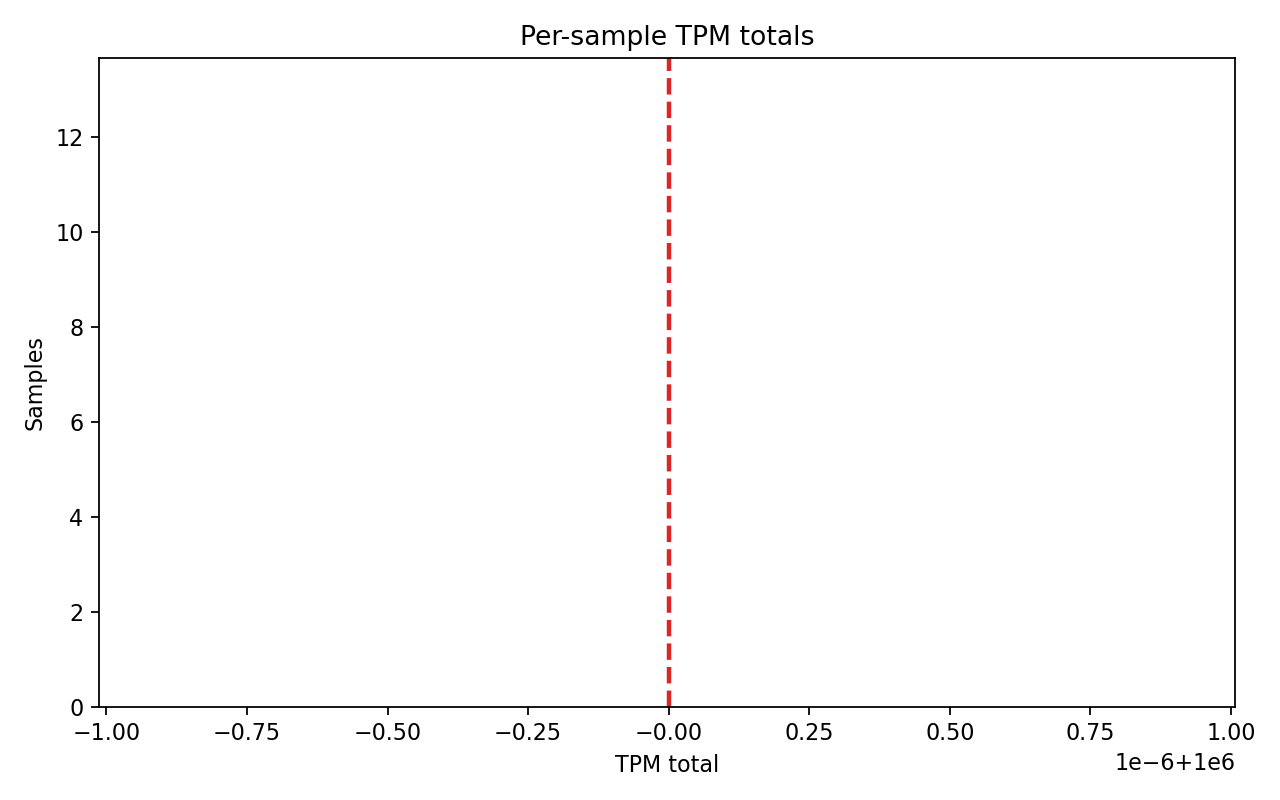

### preprocess_log1p_hist.png

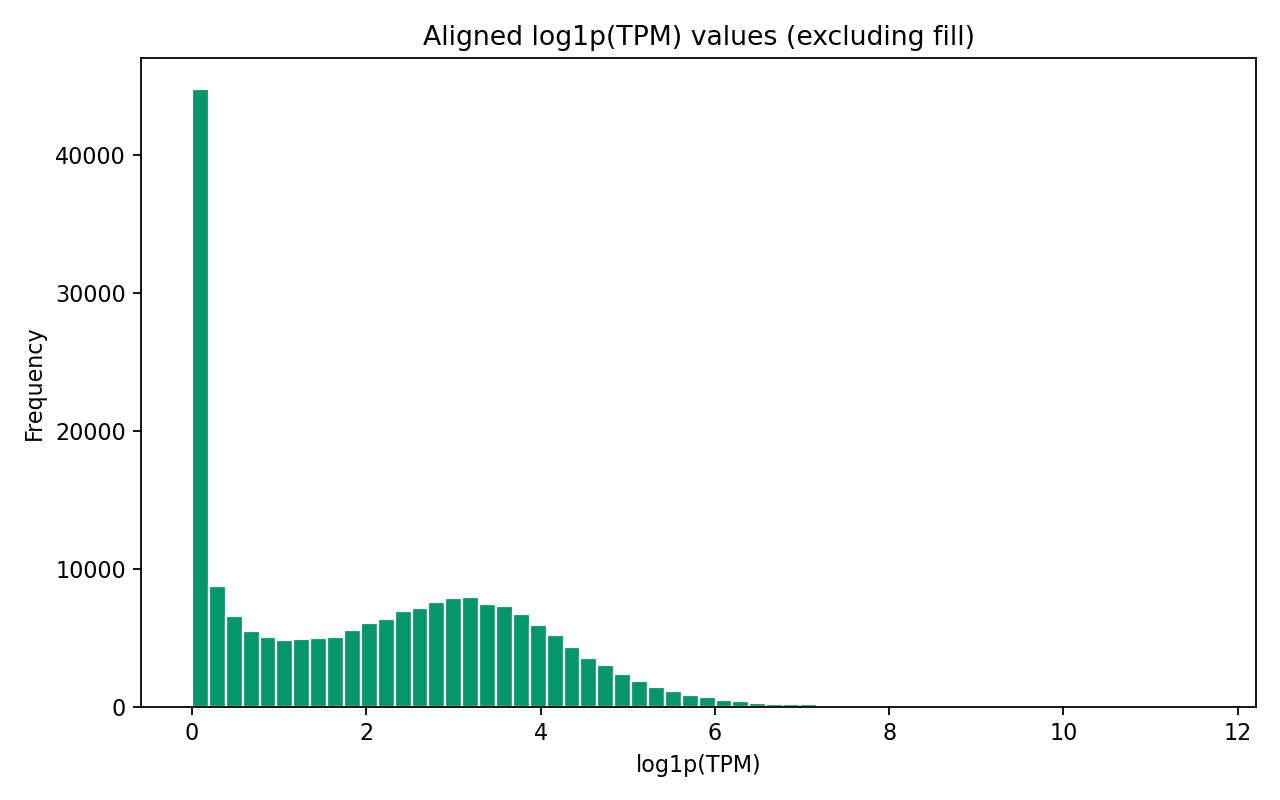

### preprocess_valid_gene_fraction.png

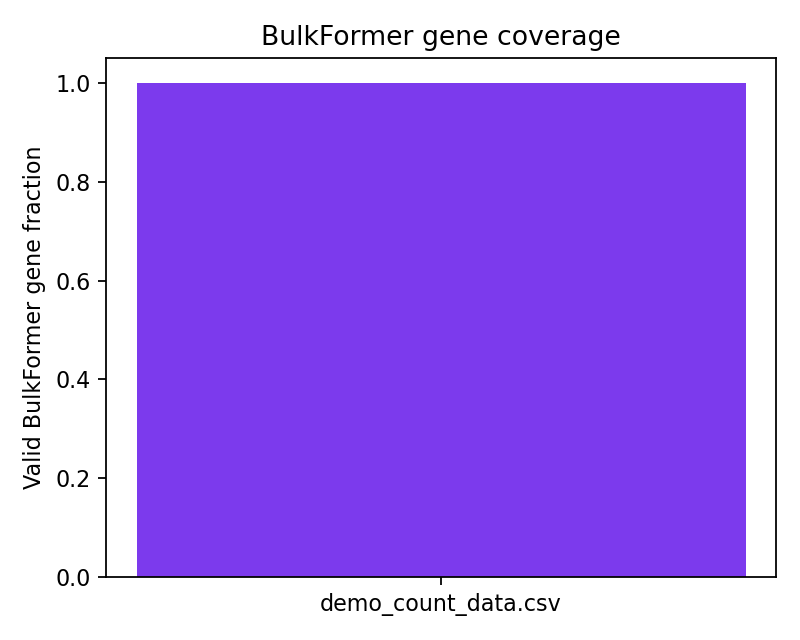

### preprocess_distribution_compare.png

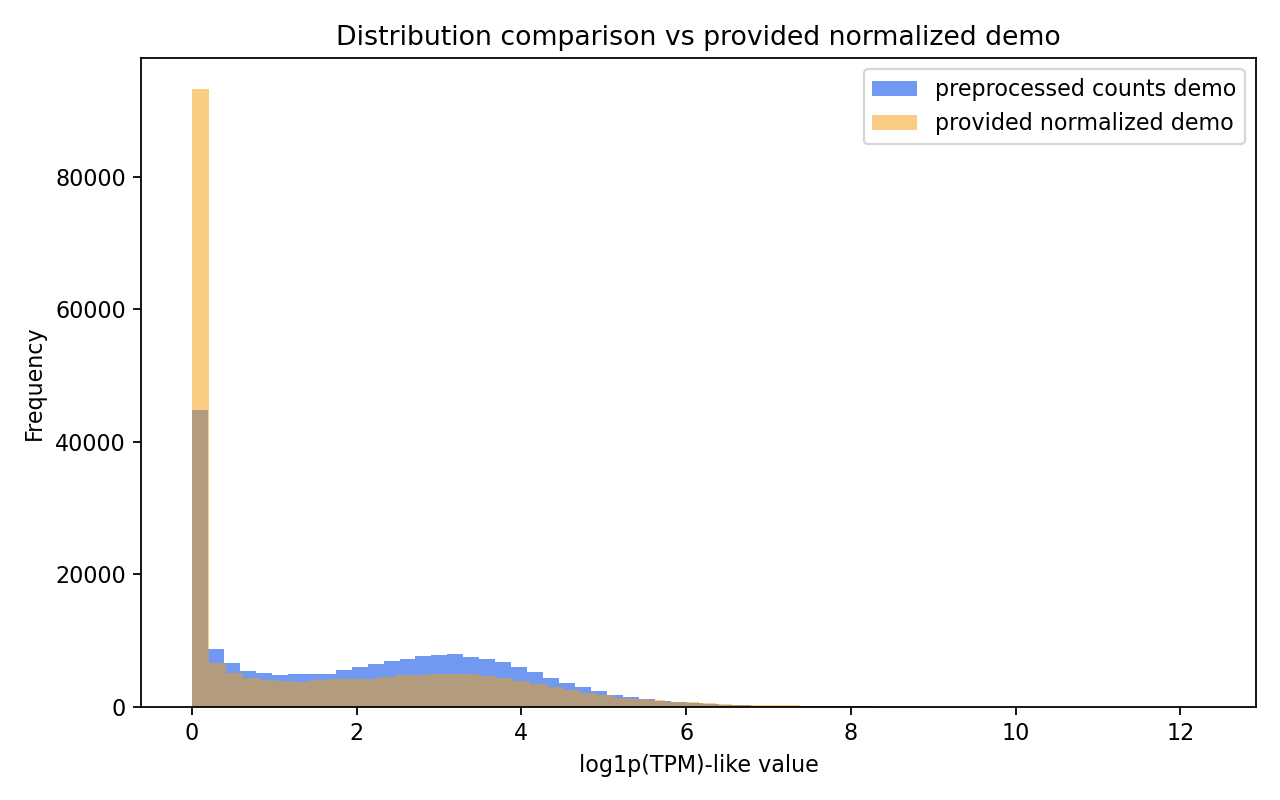

### preprocess_gene_median_compare.png

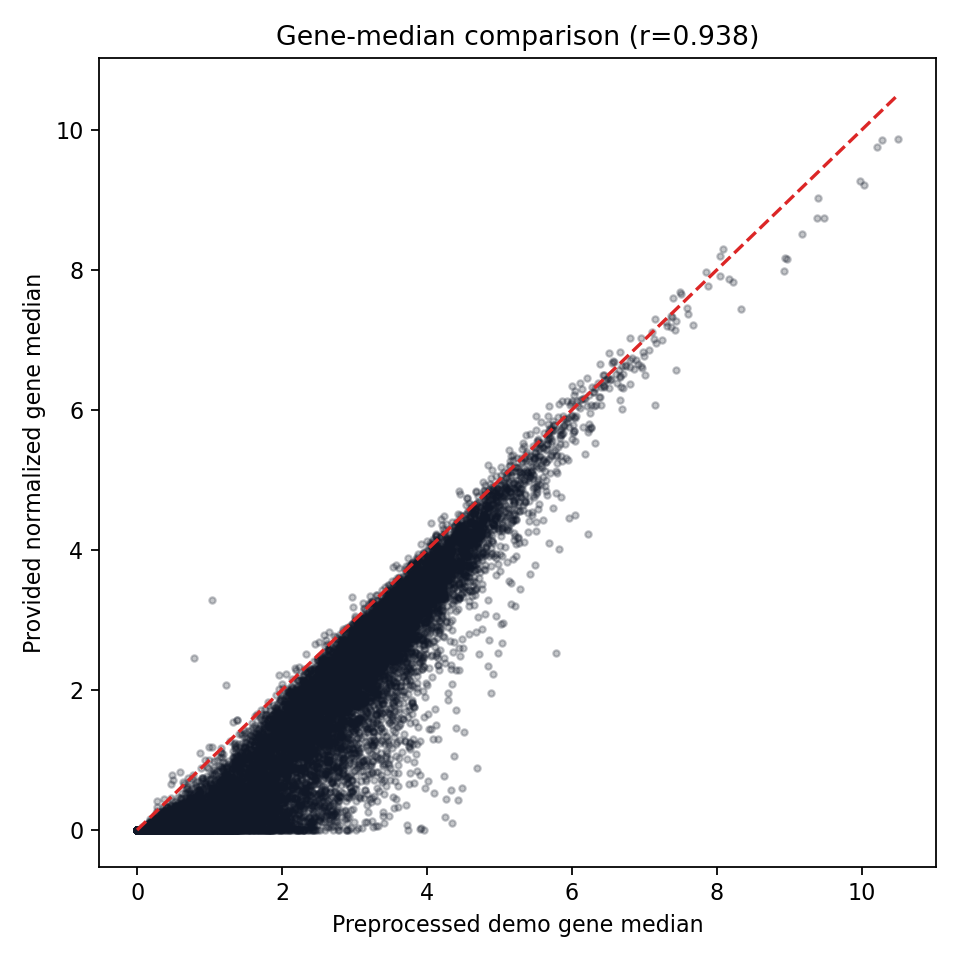

### anomaly_mean_abs_residual_hist.png

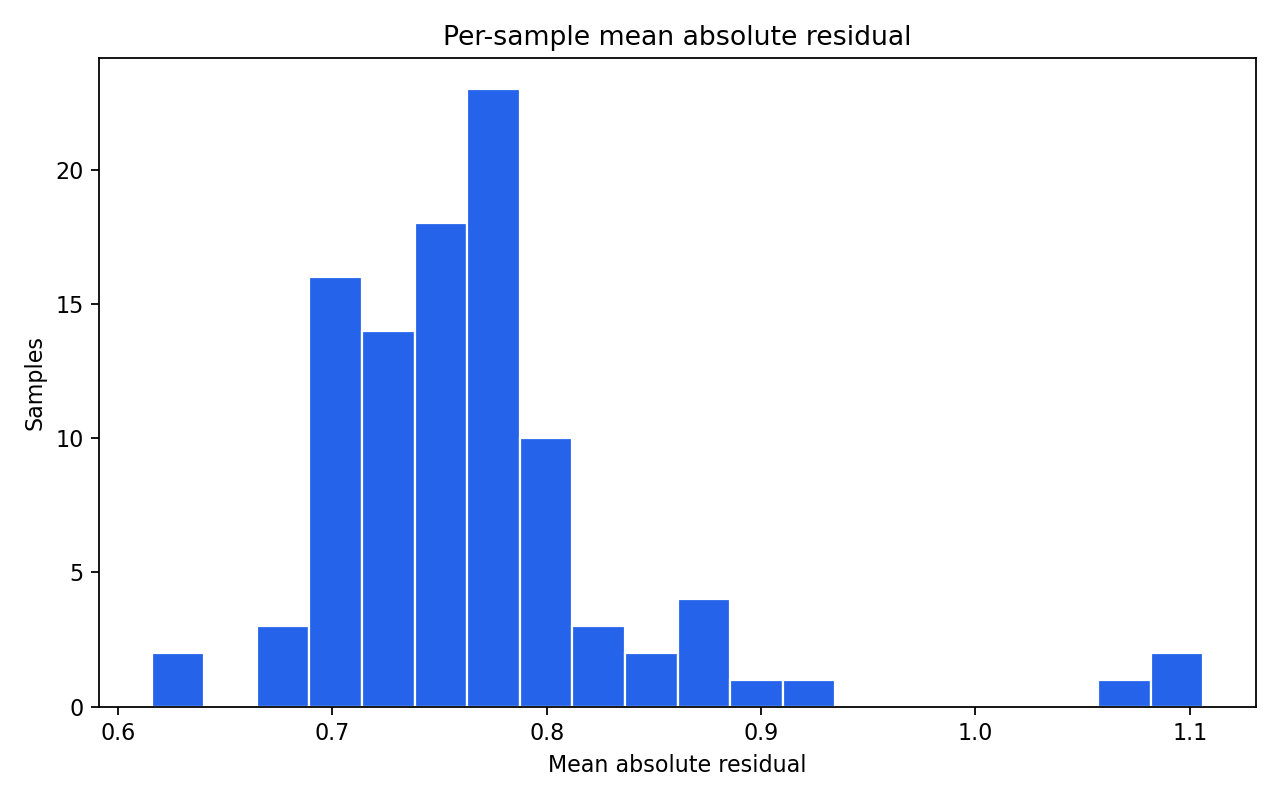

### anomaly_gene_coverage_hist.png

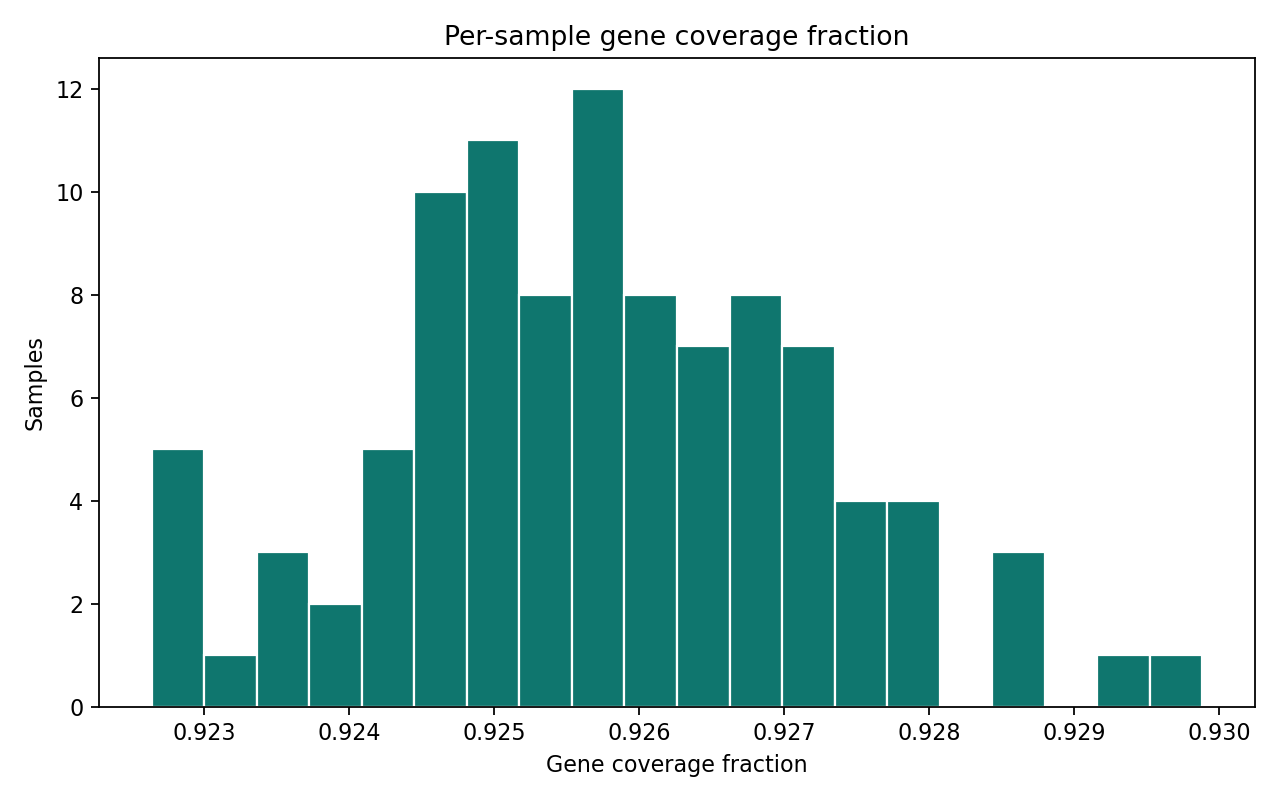

### anomaly_top50_examples.png

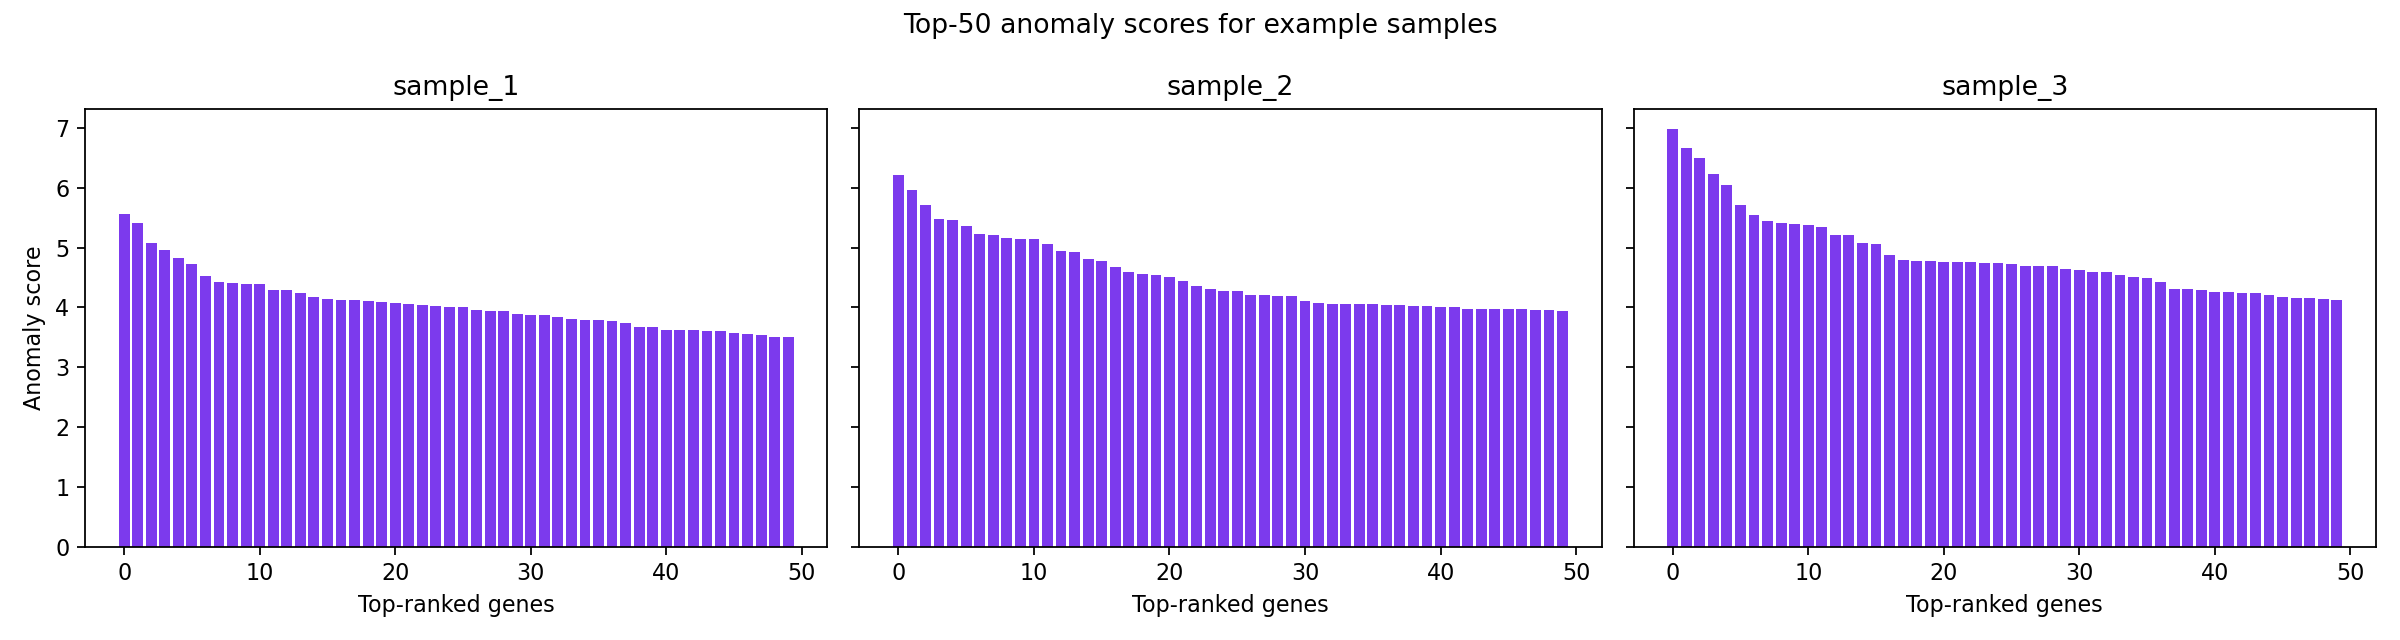

### anomaly_gene_qc_distributions.png

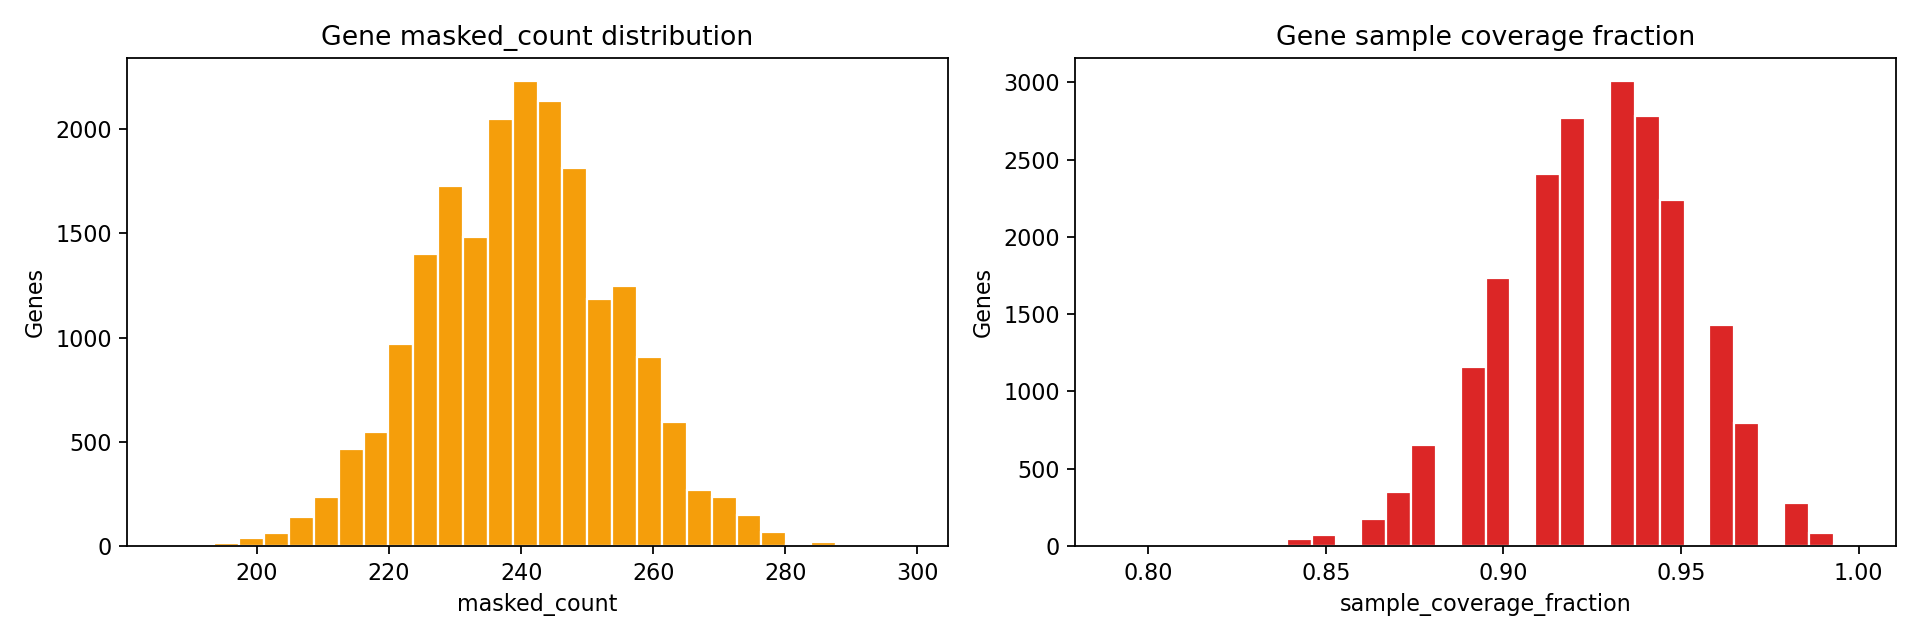

### calibration_empirical_p_hist.png

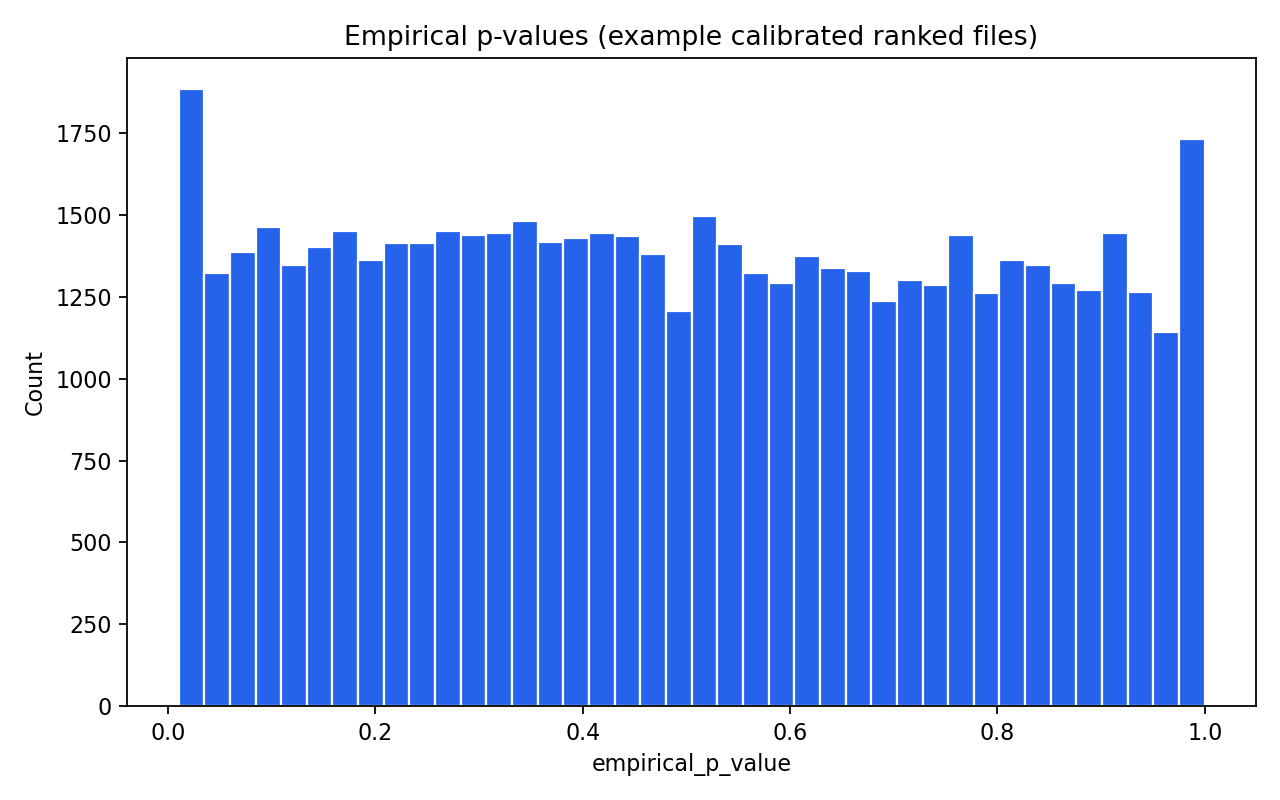

### calibration_by_q_hist.png

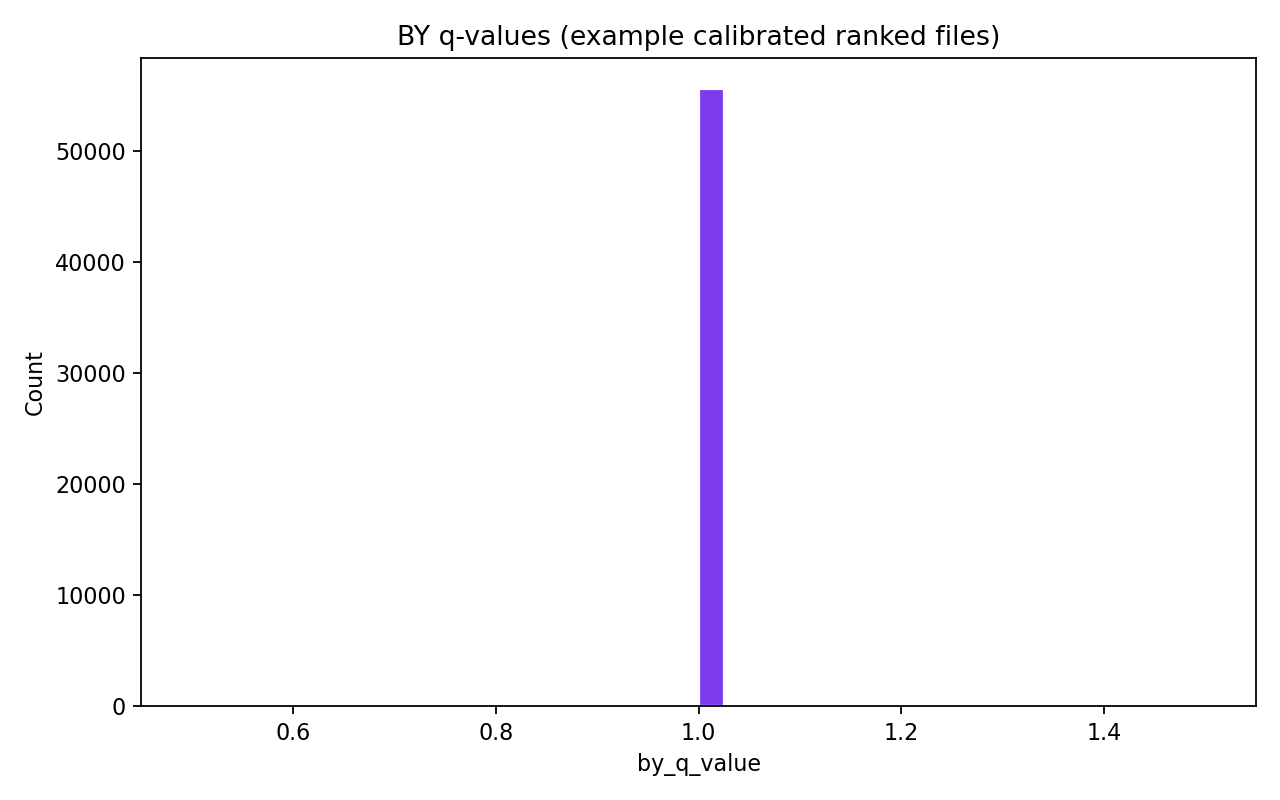

### calibration_absolute_zscore_hist.png

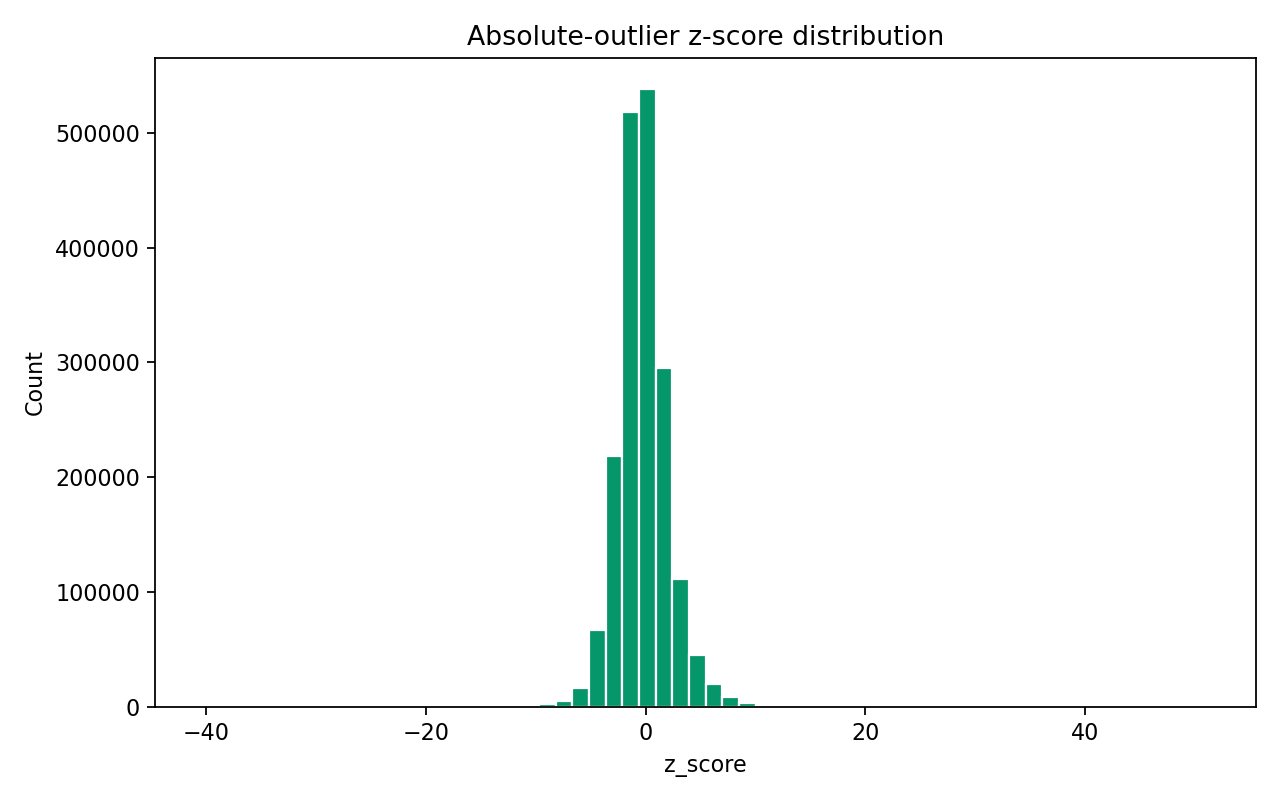

### calibration_absolute_by_p_hist.png

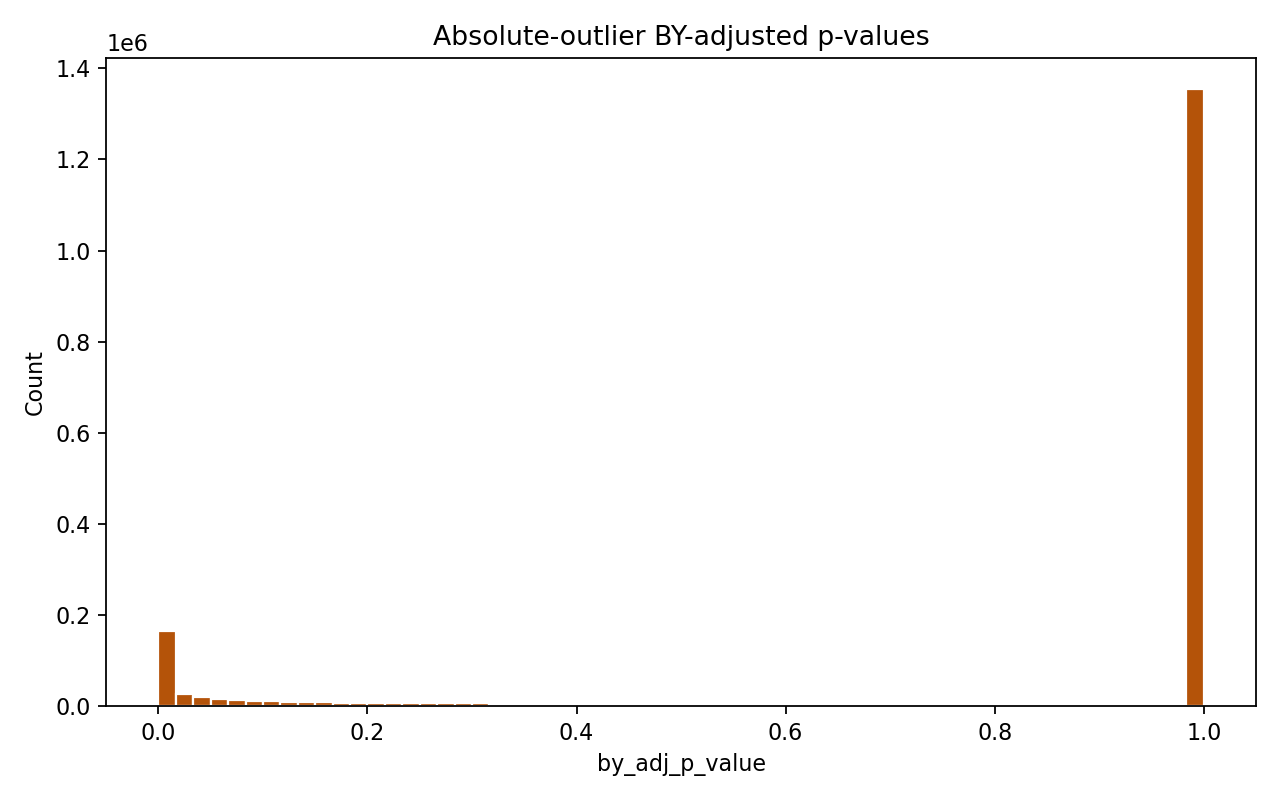

### calibration_empirical_significant_count_hist.png

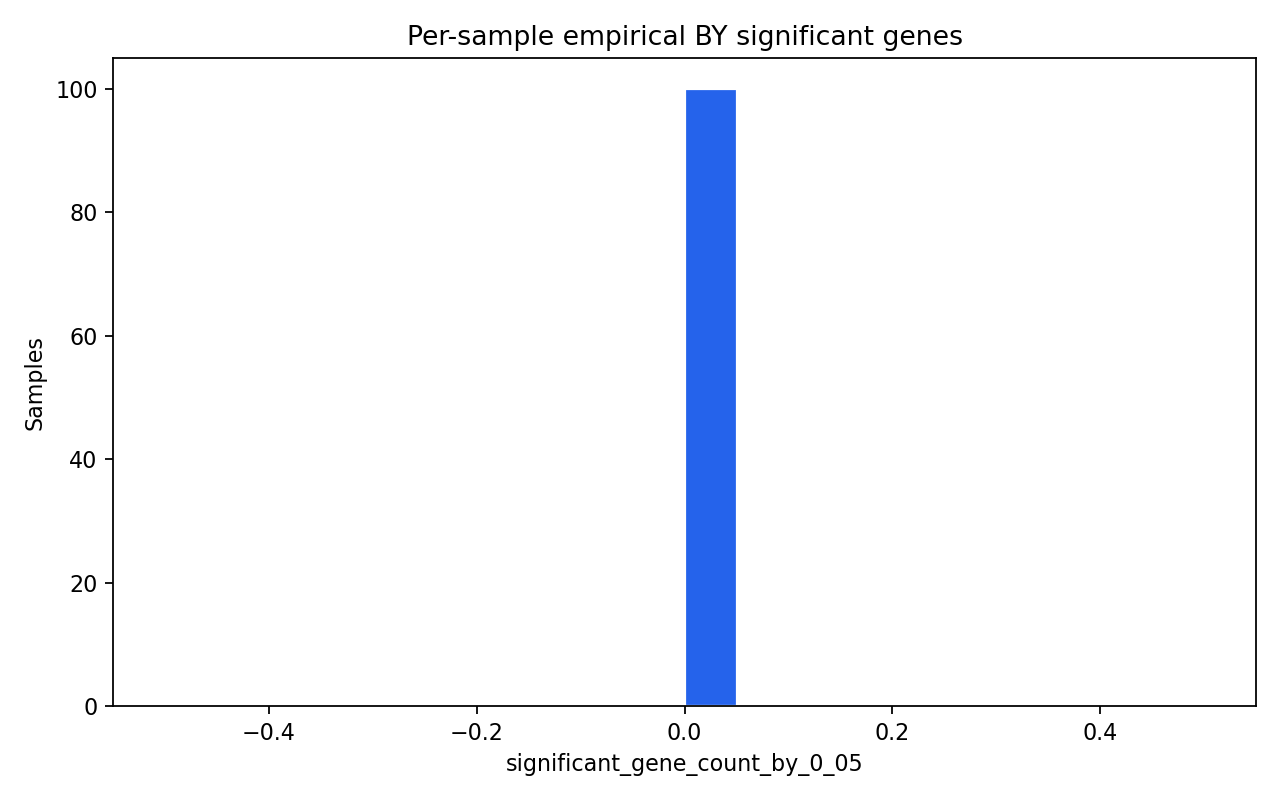

### calibration_absolute_significant_count_hist.png

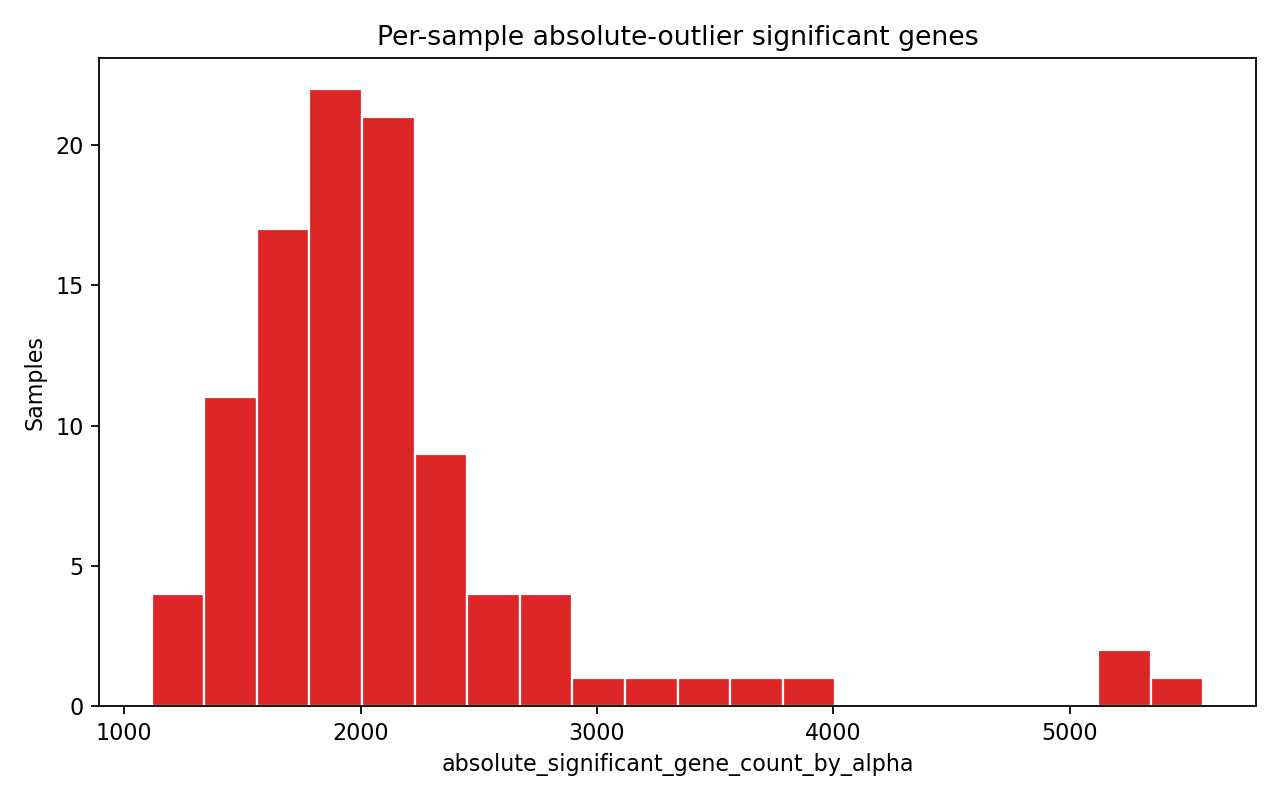

### spike_rank_shift.png

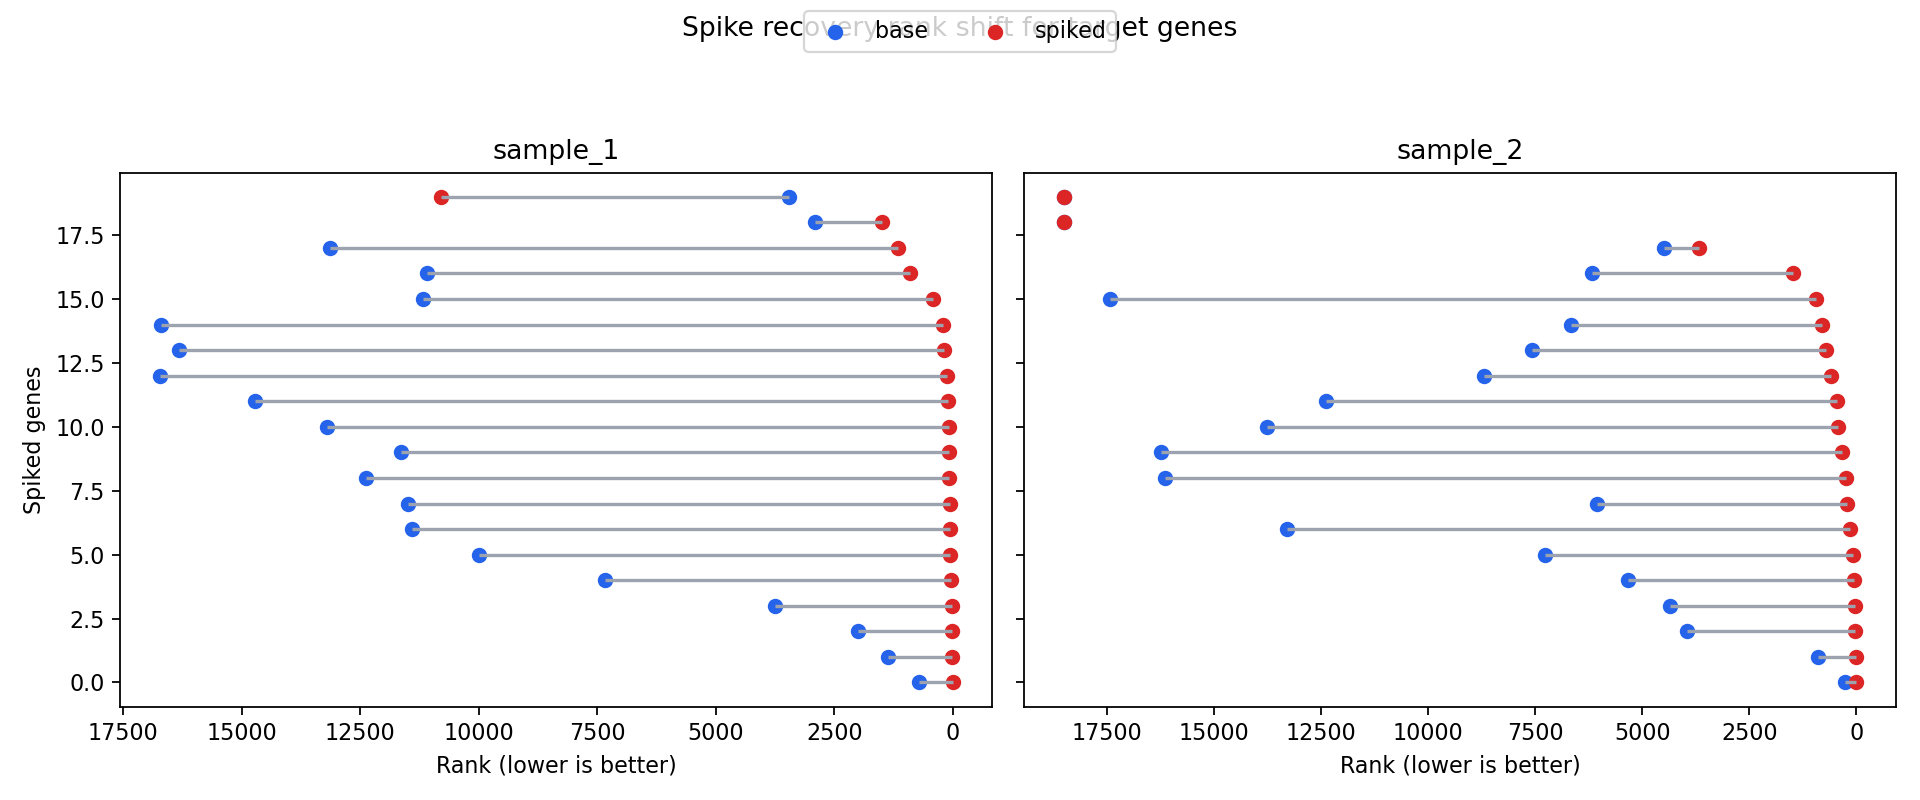

### spike_rank_improvement_hist.png

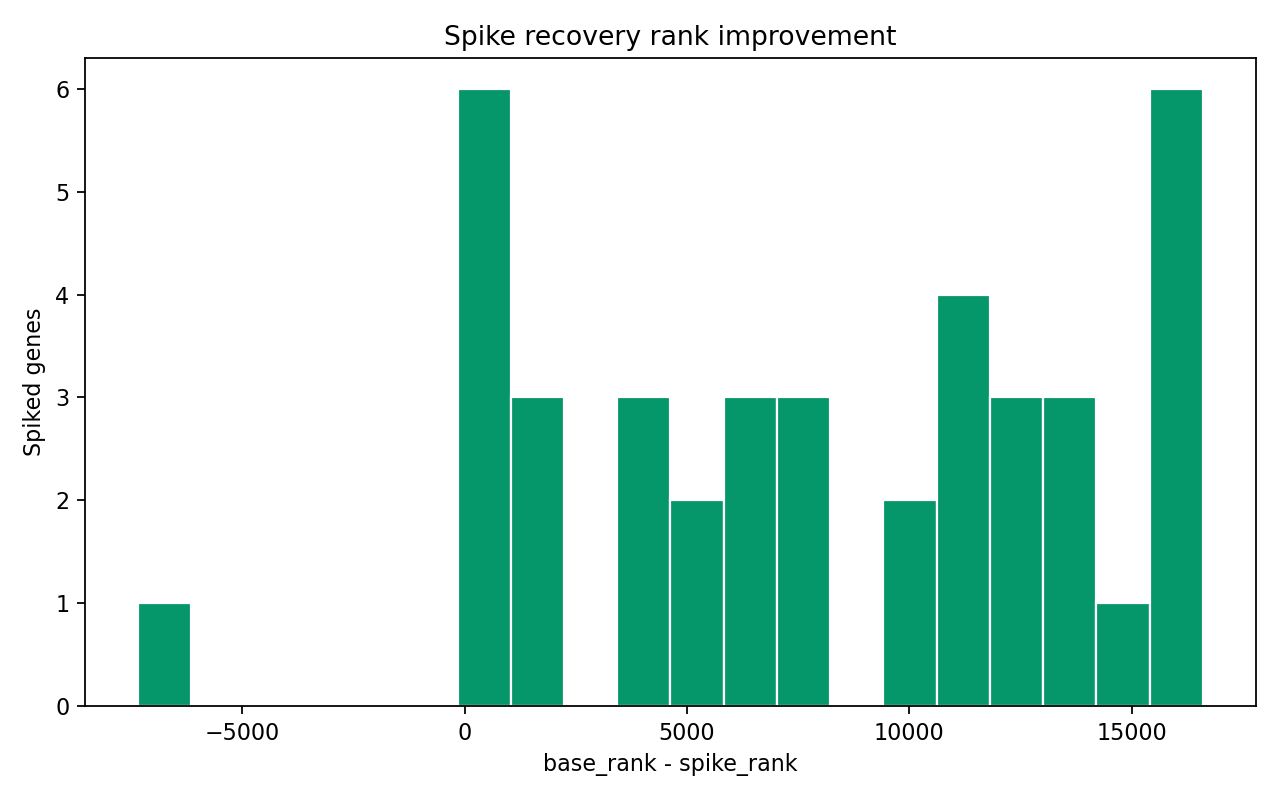

In [4]:
display(Markdown('## QC Figures'))
for figure_name in [
    'preprocess_tpm_total_hist.png',
    'preprocess_log1p_hist.png',
    'preprocess_valid_gene_fraction.png',
    'preprocess_distribution_compare.png',
    'preprocess_gene_median_compare.png',
    'anomaly_mean_abs_residual_hist.png',
    'anomaly_gene_coverage_hist.png',
    'anomaly_top50_examples.png',
    'anomaly_gene_qc_distributions.png',
    'calibration_empirical_p_hist.png',
    'calibration_by_q_hist.png',
    'calibration_absolute_zscore_hist.png',
    'calibration_absolute_by_p_hist.png',
    'calibration_empirical_significant_count_hist.png',
    'calibration_absolute_significant_count_hist.png',
    'spike_rank_shift.png',
    'spike_rank_improvement_hist.png',
]:
    display(Markdown(f'### {figure_name}'))
    display(Image(filename=str(FIGURES / figure_name)))


## Interpretation Notes

- Preprocessing looks internally consistent: TPM totals are effectively `1e6` for every sample and all `20010` BulkFormer genes are covered.
- `demo_normalized_data.csv` is not the same sample cohort as `demo_count_data.csv` (`967` rows vs `100`), so the comparison is distributional rather than one-to-one.
- The anomaly ranking path responds strongly to synthetic spikes: the spiked genes move sharply upward in rank, and many become significant in the calibrated tables.
- The empirical BY path is conservative (`0` significant genes on average), while the normalized absolute-outlier path is much more permissive and should be interpreted cautiously.
